<a href="https://colab.research.google.com/github/vedasri2511/DL-153/blob/main/WEEK7%268.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet, GoogLeNet, ResNet and note your observations. Also apply above models on your own dataset.
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, Subset
import os # Import os module to check for directory existence

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# -----------------------------
# TRANSFORM (optimized size)
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# -----------------------------
# LOAD DATASET
# -----------------------------
dataset_path = "dataset/"
try:
    # Attempt to load the user's dataset
    dataset = datasets.ImageFolder(dataset_path, transform=transform)
    print(f"Successfully loaded dataset from '{dataset_path}'")
except FileNotFoundError:
    print(f"Error: Directory '{dataset_path}' not found. Please create a directory named 'dataset/' with subfolders for each class (e.g., 'dataset/class1/img1.jpg', 'dataset/class2/img2.jpg').")
    print("Falling back to downloading CIFAR-10 dataset for demonstration purposes.")
    # Fallback to a well-known dataset for demonstration
    # CIFAR-10 images are 32x32, so the Resize(64,64) will upscale them.
    dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# reduce dataset for faster execution
dataset = Subset(dataset, range(min(200, len(dataset))))

loader = DataLoader(dataset, batch_size=16, shuffle=True)

num_classes = len(dataset.dataset.classes)

# -----------------------------
# LeNet (fixed for 64x64)
# -----------------------------
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,6,5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6,16,5),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(16*13*13,120),
            nn.ReLU(),
            nn.Linear(120,84),
            nn.ReLU(),
            nn.Linear(84,num_classes)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

model_lenet = LeNet().to(device)

# -----------------------------
# AlexNet (freeze layers)
# -----------------------------
model_alexnet = models.alexnet(pretrained=True)
for param in model_alexnet.parameters():
    param.requires_grad = False
model_alexnet.classifier[6] = nn.Linear(4096, num_classes)
model_alexnet = model_alexnet.to(device)

# -----------------------------
# ZF-Net (modified AlexNet)
# -----------------------------
model_zf = models.alexnet(pretrained=True)
for param in model_zf.parameters():
    param.requires_grad = False
model_zf.features[0] = nn.Conv2d(3,96,7,2)
# Fix: Update the in_channels of the subsequent convolutional layer (features[3])
model_zf.features[3] = nn.Conv2d(96, 192, kernel_size=5, stride=1, padding=2)
model_zf.classifier[6] = nn.Linear(4096, num_classes)
model_zf = model_zf.to(device)

# -----------------------------
# VGG16
# -----------------------------
model_vgg = models.vgg16(pretrained=True)
for param in model_vgg.parameters():
    param.requires_grad = False
model_vgg.classifier[6] = nn.Linear(4096, num_classes)
model_vgg = model_vgg.to(device)

# -----------------------------
# GoogLeNet
# -----------------------------
model_google = models.googlenet(pretrained=True)
for param in model_google.parameters():
    param.requires_grad = False
model_google.fc = nn.Linear(1024, num_classes)
model_google = model_google.to(device)

# -----------------------------
# ResNet18
# -----------------------------
model_resnet = models.resnet18(pretrained=True)
for param in model_resnet.parameters():
    param.requires_grad = False
model_resnet.fc = nn.Linear(512, num_classes)
model_resnet = model_resnet.to(device)

# -----------------------------
# TRAIN FUNCTION (FAST)
# -----------------------------
def train(model, name):
    print(f"\nTraining {name}...\n")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    model.train()

    for epoch in range(2):
        total_loss = 0

        for i, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if i % 5 == 0:
                print(f"{name} | Epoch {epoch} | Batch {i} | Loss {loss.item()}")

        print(f"{name} | Epoch {epoch} Completed | Avg Loss {total_loss/len(loader)}")

# -----------------------------
# TRAIN MODELS (one by one)
# -----------------------------
train(model_lenet, "LeNet")
train(model_alexnet, "AlexNet")
train(model_zf, "ZF-Net")
train(model_vgg, "VGG16")
train(model_google, "GoogLeNet")
train(model_resnet, "ResNet18")

cpu
Error: Directory 'dataset/' not found. Please create a directory named 'dataset/' with subfolders for each class (e.g., 'dataset/class1/img1.jpg', 'dataset/class2/img2.jpg').
Falling back to downloading CIFAR-10 dataset for demonstration purposes.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  w


Training LeNet...

LeNet | Epoch 0 | Batch 0 | Loss 2.3157246112823486
LeNet | Epoch 0 | Batch 5 | Loss 2.3255507946014404
LeNet | Epoch 0 | Batch 10 | Loss 2.3322603702545166
LeNet | Epoch 0 Completed | Avg Loss 2.309596061706543
LeNet | Epoch 1 | Batch 0 | Loss 2.2691664695739746
LeNet | Epoch 1 | Batch 5 | Loss 2.2681965827941895
LeNet | Epoch 1 | Batch 10 | Loss 2.320646286010742
LeNet | Epoch 1 Completed | Avg Loss 2.2901181991283712

Training AlexNet...

AlexNet | Epoch 0 | Batch 0 | Loss 2.499417543411255
AlexNet | Epoch 0 | Batch 5 | Loss 2.5395522117614746
AlexNet | Epoch 0 | Batch 10 | Loss 2.6408324241638184
AlexNet | Epoch 0 Completed | Avg Loss 2.702902445426354
AlexNet | Epoch 1 | Batch 0 | Loss 1.1585559844970703
AlexNet | Epoch 1 | Batch 5 | Loss 0.926784098148346
AlexNet | Epoch 1 | Batch 10 | Loss 1.4895892143249512
AlexNet | Epoch 1 Completed | Avg Loss 1.217303610765017

Training ZF-Net...

ZF-Net | Epoch 0 | Batch 0 | Loss 2.5989651679992676
ZF-Net | Epoch 0 | Bat

'sample.jpg' not found. Downloading a sample image...
17046/17046 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step


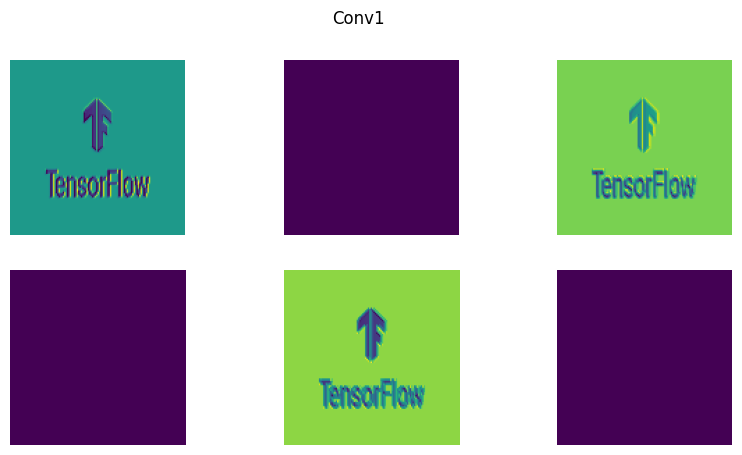

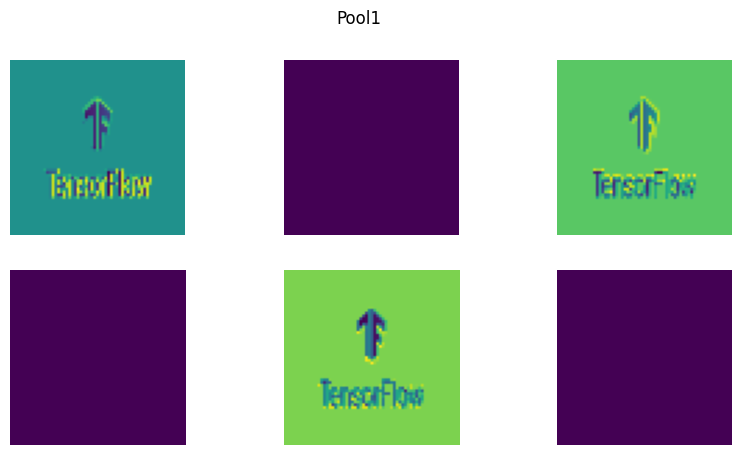

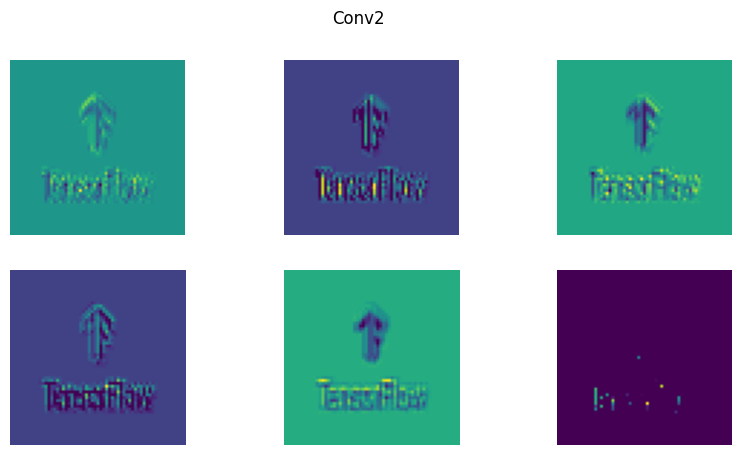

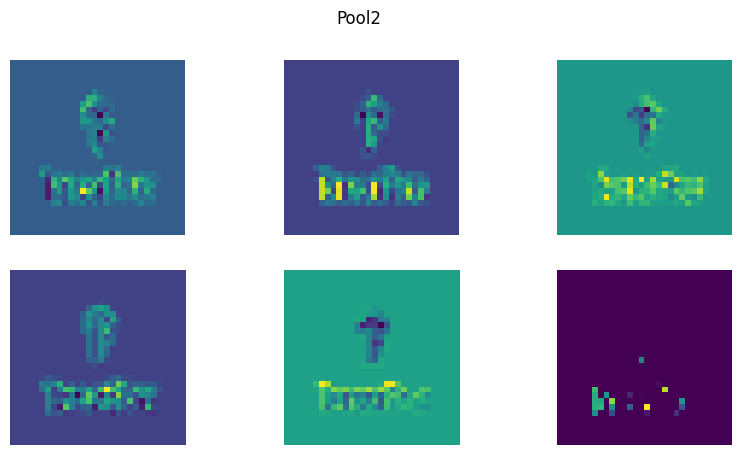

In [2]:
#Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras.preprocessing import image
import tensorflow as tf

img_path = 'sample.jpg'
try:
    img = image.load_img(img_path, target_size=(128, 128))
except FileNotFoundError:
    print(f"'{img_path}' not found. Downloading a sample image...")
    image_url = "https://www.tensorflow.org/images/tf_logo_social.png"
    # tf.keras.utils.get_file downloads the file to a temporary directory and returns its path
    img_path = tf.keras.utils.get_file("tf_logo_social.png", image_url)
    img = image.load_img(img_path, target_size=(128, 128))

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

input_layer = Input(shape=(128,128,3))

conv1 = Conv2D(8, (3,3), activation='relu')(input_layer)
pool1 = MaxPooling2D((2,2))(conv1)

conv2 = Conv2D(16, (3,3), activation='relu')(pool1)
pool2 = MaxPooling2D((2,2))(conv2)

model = Model(inputs=input_layer, outputs=[conv1, pool1, conv2, pool2])

feature_maps = model.predict(img_array)

layer_names = ['Conv1', 'Pool1', 'Conv2', 'Pool2']

for fmap, name in zip(feature_maps, layer_names):
    plt.figure(figsize=(10,5))
    for i in range(min(6, fmap.shape[-1])):
        plt.subplot(2,3,i+1)
        plt.imshow(fmap[0,:,:,i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(name)
    plt.show()

'sample.jpg' not found. Downloading a sample image...


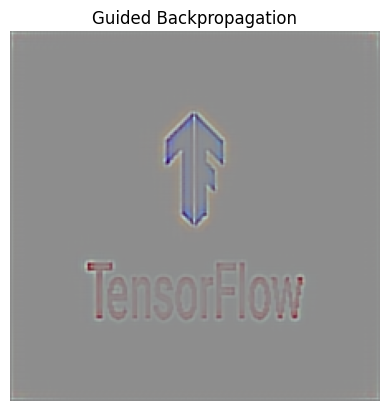

In [5]:
#Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

model = tf.keras.applications.VGG16(weights='imagenet')

img_path = 'sample.jpg'
try:
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
except FileNotFoundError:
    print(f"'{img_path}' not found. Downloading a sample image...")
    image_url = "https://www.tensorflow.org/images/tf_logo_social.png"
    img_path = tf.keras.utils.get_file("tf_logo_social.png", image_url)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

with tf.GradientTape() as tape:
    inputs = tf.cast(img_array, tf.float32)
    tape.watch(inputs)
    preds = model(inputs)
    loss = preds[:, np.argmax(preds[0])]

grads = tape.gradient(loss, inputs)[0]

# Corrected: Use tf.reduce_min and tf.reduce_max for TensorFlow tensors
grads = (grads - tf.reduce_min(grads)) / (tf.reduce_max(grads) - tf.reduce_min(grads))

plt.imshow(grads)
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()